In [ ]:
input_folder = "/content/drive/MyDrive/techniqueComparison/y"

In [ ]:
import os
files = os.listdir(input_folder)

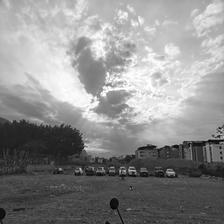

In [ ]:
from PIL import Image
Image.open(input_folder + "/" + files[0])

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.restoration import denoise_wavelet, denoise_tv_chambolle, cycle_spin
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as calc_psnr

# ==========================================
# 1. SPECIALIST FILTERS
# ==========================================
def run_wavelet(image):
    """Path A: Wavelets"""
    def wavelet_func(img):
        return denoise_wavelet(img, method='BayesShrink', mode='soft', wavelet='sym4', rescale_sigma=True)
    return cycle_spin(image, func=wavelet_func, max_shifts=3)

def run_tv(image):
    """Path B: Total Variation"""
    return denoise_tv_chambolle(image, weight=0.1)

# ==========================================
# 2. MAIN EVALUATION LOOP
# ==========================================
def main():
    folder_path = "y"

    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return

    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in sorted(os.listdir(folder_path)) if f.lower().endswith(valid_ext)]
    total_images = len(image_files)

    if total_images == 0:
        print("No valid images found.")
        return

    print(f"Found {total_images} images. Starting Dynamic Evaluation...\n")

    # Pick 4 random images to visualize later
    num_to_display = min(4, total_images)
    display_indices = set(random.sample(range(total_images), num_to_display))
    display_data = []

    # Storage for dataset metrics
    results = {
        'g_noisy_psnr': [], 'g_psnr': [], 'g_w': [],
        'p_noisy_psnr': [], 'p_psnr': [], 'p_w': []
    }

    test_weights = np.linspace(0.0, 1.0, 11)

    for idx, filename in enumerate(image_files):
        # Clean Progress Tracker (updates on the same line)
        print(f"Processing image {idx + 1} of {total_images}...", end='\r')

        image_path = os.path.join(folder_path, filename)
        raw_img = io.imread(image_path, as_gray=True)
        original = img_as_float(raw_img).astype(np.float32)

        # Add Noise
        noisy_g = random_noise(original, mode='gaussian', var=0.0225, clip=True).astype(np.float32)
        noisy_p = random_noise(original, mode='poisson', clip=True).astype(np.float32)

        # Baseline Noisy PSNR
        baseline_psnr_g = calc_psnr(original, noisy_g, data_range=1.0)
        baseline_psnr_p = calc_psnr(original, noisy_p, data_range=1.0)

        # Apply Base Filters
        w_g, tv_g = run_wavelet(noisy_g), run_tv(noisy_g)
        w_p, tv_p = run_wavelet(noisy_p), run_tv(noisy_p)

        # Find Best Weights
        psnr_g_list = [calc_psnr(original, np.clip((w * w_g) + ((1-w) * tv_g), 0, 1), data_range=1.0) for w in test_weights]
        psnr_p_list = [calc_psnr(original, np.clip((w * w_p) + ((1-w) * tv_p), 0, 1), data_range=1.0) for w in test_weights]

        best_g_idx, best_p_idx = np.argmax(psnr_g_list), np.argmax(psnr_p_list)
        best_g_w, best_p_w = test_weights[best_g_idx], test_weights[best_p_idx]
        best_g_psnr, best_p_psnr = psnr_g_list[best_g_idx], psnr_p_list[best_p_idx]

        # Save metrics
        results['g_noisy_psnr'].append(baseline_psnr_g)
        results['g_psnr'].append(best_g_psnr)
        results['g_w'].append(best_g_w)

        results['p_noisy_psnr'].append(baseline_psnr_p)
        results['p_psnr'].append(best_p_psnr)
        results['p_w'].append(best_p_w)

        # Cache visual data
        if idx in display_indices:
            best_fused_g = np.clip((best_g_w * w_g) + ((1-best_g_w) * tv_g), 0, 1)
            best_fused_p = np.clip((best_p_w * w_p) + ((1-best_p_w) * tv_p), 0, 1)

            display_data.append({
                'filename': filename, 'orig': original,
                'n_g': noisy_g, 'n_g_psnr': baseline_psnr_g,
                'd_g': best_fused_g, 'd_g_psnr': best_g_psnr, 'w_g': best_g_w,
                'n_p': noisy_p, 'n_p_psnr': baseline_psnr_p,
                'd_p': best_fused_p, 'd_p_psnr': best_p_psnr, 'w_p': best_p_w
            })

    # Clear the progress line when done
    print(f"\nSuccessfully evaluated all {total_images} images.")

    # ==========================================
    # 3. PRINT TOTAL AVERAGES
    # ==========================================
    if not results['g_psnr']: return

    print("\n" + "█"*50)
    print(" FINAL DATASET AVERAGES (DYNAMIC ENSEMBLE) ")
    print("█"*50)
    print("\n[ GAUSSIAN NOISE ]")
    print(f"Average Noisy PSNR    : {np.mean(results['g_noisy_psnr']):.2f} dB")
    print(f"Average Denoised PSNR : {np.mean(results['g_psnr']):.2f} dB")
    print(f"Average Improvement   : +{np.mean(results['g_psnr']) - np.mean(results['g_noisy_psnr']):.2f} dB")

    print("\n[ POISSON NOISE ]")
    print(f"Average Noisy PSNR    : {np.mean(results['p_noisy_psnr']):.2f} dB")
    print(f"Average Denoised PSNR : {np.mean(results['p_psnr']):.2f} dB")
    print(f"Average Improvement   : +{np.mean(results['p_psnr']) - np.mean(results['p_noisy_psnr']):.2f} dB")
    print("█"*50 + "\n")

    # ==========================================
    # 4. PLOTTING GRAPHS
    # ==========================================

    # --- FIGURE 1: 4 Random Image Visuals ---
    fig1, axes = plt.subplots(num_to_display, 5, figsize=(20, 4 * num_to_display))
    fig1.suptitle("Dynamic Ensemble Results: 4 Randomly Sampled Images", fontsize=18, fontweight='bold')

    if num_to_display == 1: axes = [axes]

    for row_idx, data in enumerate(display_data):
        ax_row = axes[row_idx]

        ax_row[0].imshow(data['orig'], cmap='gray', vmin=0, vmax=1)
        ax_row[0].set_title(f"Original\n({data['filename']})", fontweight='bold')

        ax_row[1].imshow(data['n_g'], cmap='gray', vmin=0, vmax=1)
        ax_row[1].set_title(f"Gaussian Noise\nPSNR: {data['n_g_psnr']:.2f} dB")

        ax_row[2].imshow(data['d_g'], cmap='gray', vmin=0, vmax=1)
        ax_row[2].set_title(f"Corrected (G)\nPSNR: {data['d_g_psnr']:.2f} dB\nWav: {data['w_g']:.1f} | TV: {1.0-data['w_g']:.1f}", color='blue')

        ax_row[3].imshow(data['n_p'], cmap='gray', vmin=0, vmax=1)
        ax_row[3].set_title(f"Poisson Noise\nPSNR: {data['n_p_psnr']:.2f} dB")

        ax_row[4].imshow(data['d_p'], cmap='gray', vmin=0, vmax=1)
        ax_row[4].set_title(f"Corrected (P)\nPSNR: {data['d_p_psnr']:.2f} dB\nWav: {data['w_p']:.1f} | TV: {1.0-data['w_p']:.1f}", color='green')

        for ax in ax_row:
            ax.axis('off')

    plt.tight_layout()

    # --- FIGURE 2: Dataset Analytics Dashboard ---
    fig2, (ax_w, ax_g, ax_p) = plt.subplots(3, 1, figsize=(12, 14))
    fig2.suptitle('Dataset Analytics Dashboard', fontsize=16, fontweight='bold')
    img_indices = np.arange(1, total_images + 1)

    # Top Chart: Dynamic Weight Selection
    ax_w.plot(img_indices, results['g_w'], marker='o', color='royalblue', label='Gaussian Chosen Wavelet Weight', alpha=0.8)
    ax_w.plot(img_indices, results['p_w'], marker='s', color='forestgreen', label='Poisson Chosen Wavelet Weight', alpha=0.8)
    ax_w.set_title('Dynamic Weight Selection Fluctuation', fontweight='bold')
    ax_w.set_ylabel('Wavelet Weight (0.0 to 1.0)')
    ax_w.set_yticks(test_weights)
    ax_w.legend(loc='center right')
    ax_w.grid(True, linestyle='--', alpha=0.5)

    # Middle Chart: Gaussian Noise vs Corrected
    ax_g.plot(img_indices, results['g_noisy_psnr'], color='red', linestyle='--', label='Original Gaussian Noise PSNR')
    ax_g.plot(img_indices, results['g_psnr'], color='royalblue', linewidth=2, label='Corrected PSNR (Ensemble)')
    ax_g.fill_between(img_indices, results['g_noisy_psnr'], results['g_psnr'], color='royalblue', alpha=0.2, label='Improvement Gap')
    ax_g.set_title('Gaussian: Noise vs. Corrected Image Quality', fontweight='bold')
    ax_g.set_ylabel('PSNR (dB)')
    ax_g.legend(loc='lower right')
    ax_g.grid(True, linestyle='--', alpha=0.5)

    # Bottom Chart: Poisson Noise vs Corrected
    ax_p.plot(img_indices, results['p_noisy_psnr'], color='red', linestyle='--', label='Original Poisson Noise PSNR')
    ax_p.plot(img_indices, results['p_psnr'], color='forestgreen', linewidth=2, label='Corrected PSNR (Ensemble)')
    ax_p.fill_between(img_indices, results['p_noisy_psnr'], results['p_psnr'], color='forestgreen', alpha=0.2, label='Improvement Gap')
    ax_p.set_title('Poisson: Noise vs. Corrected Image Quality', fontweight='bold')
    ax_p.set_xlabel('Image Index in Dataset')
    ax_p.set_ylabel('PSNR (dB)')
    ax_p.legend(loc='lower right')
    ax_p.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()

    print("Opening analytical graphs...")
    plt.show()

# if __name__ == "__main__":
#     main()

In [ ]:
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
import numpy as np

def process_single_image(img):
    img = img.astype(np.float32)

    # Add noise
    noisy_g = random_noise(img, mode='gaussian', var=0.0225, clip=True)
    noisy_p = random_noise(img, mode='poisson', clip=True)

    # Apply filters
    w_g, tv_g = run_wavelet(noisy_g), run_tv(noisy_g)
    w_p, tv_p = run_wavelet(noisy_p), run_tv(noisy_p)

    test_weights = np.linspace(0, 1, 11)

    # Best fusion (Gaussian)
    psnr_g_list = [
        calc_psnr(img, np.clip(w*w_g + (1-w)*tv_g, 0, 1), data_range=1.0)
        for w in test_weights
    ]
    best_g = max(psnr_g_list)

    # Best fusion (Poisson)
    psnr_p_list = [
        calc_psnr(img, np.clip(w*w_p + (1-w)*tv_p, 0, 1), data_range=1.0)
        for w in test_weights
    ]
    best_p = max(psnr_p_list)

    return best_g, best_p

In [ ]:
img = Image.open(input_folder + "/" + files[0]).convert("L")
img = np.array(img) / 255.0

g_psnr, p_psnr = process_single_image(img)

print("Gaussian PSNR:", g_psnr)
print("Poisson PSNR:", p_psnr)

Gaussian PSNR: 27.26451502963396
Poisson PSNR: 32.39996083513443


##Now Let's Try adding noises and using filters all together on full dataset

In [ ]:
def add_combined_noise(img):
    noisy_p = random_noise(img, mode='poisson')
    noisy_gp = random_noise(noisy_p, mode='gaussian', var=0.0225)
    return noisy_gp

In [ ]:
from scipy.ndimage import gaussian_filter, median_filter
import cv2

def apply_all_filters(noisy):
    results = {}

    results['wavelet'] = run_wavelet(noisy)
    results['tv'] = run_tv(noisy)
    results['gaussian'] = gaussian_filter(noisy, sigma=1)
    results['median'] = median_filter(noisy, size=3)
    results['bilateral'] = cv2.bilateralFilter(noisy.astype('float32'), 9, 75, 75)

    return results

In [ ]:
results = []

for file in files:
    img = np.array(Image.open(input_folder + "/" + file).convert("L")) / 255.0

    # Noise types
    noises = {
        "gaussian": random_noise(img, mode='gaussian', var=0.0225),
        "poisson": random_noise(img, mode='poisson'),
        "combined": add_combined_noise(img)
    }

    for noise_name, noisy in noises.items():
        filtered = apply_all_filters(noisy)

        for method, denoised in filtered.items():
            psnr = calc_psnr(img, denoised, data_range=1.0)

            results.append({
                "image": file,
                "noise": noise_name,
                "method": method,
                "psnr": psnr
            })

In [ ]:
import pandas as pd

df = pd.DataFrame(results)

pivot = df.pivot_table(index="method", columns="noise", values="psnr", aggfunc="mean")

print(pivot)

noise       combined   gaussian    poisson
method                                    
bilateral  21.424054  21.467760  21.869459
gaussian   23.118841  23.272793  25.389826
median     21.438994  21.646522  25.331598
tv         23.840817  24.062398  25.739085
wavelet    23.379490  23.581403  30.166228


### From the above output, we can say that Total Variation provides the most stable performance across noise types, while Wavelet denoising excels specifically for Poisson noise due to its frequency-domain representation.

In [ ]:
import matplotlib.pyplot as plt
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np
import cv2
from scipy.ndimage import gaussian_filter, median_filter

def visualize_full_pipeline(img):

    # -------- Noise --------
    noisy_g = random_noise(img, mode='gaussian', var=0.0225)
    noisy_p = random_noise(img, mode='poisson')
    noisy_c = random_noise(noisy_p, mode='gaussian', var=0.0225)

    noises = {
        "Gaussian": noisy_g,
        "Poisson": noisy_p,
        "Combined": noisy_c
    }

    for noise_name, noisy in noises.items():

        # -------- Filters --------
        wave = run_wavelet(noisy)
        tv = run_tv(noisy)
        gauss = gaussian_filter(noisy, sigma=1)
        med = median_filter(noisy, size=3)
        bil = cv2.bilateralFilter(noisy.astype('float32'), 9, 75, 75)

        # -------- SHOW SEPARATE --------
        fig1, ax1 = plt.subplots(2, 4, figsize=(12,6))

        ax1[0,0].imshow(img, cmap='gray')
        ax1[0,0].set_title("Original")

        ax1[0,1].imshow(noisy, cmap='gray')
        ax1[0,1].set_title(f"{noise_name} Noise")

        ax1[0,2].imshow(wave, cmap='gray')
        ax1[0,2].set_title(f"Wavelet\n{psnr(img,wave):.2f}")

        ax1[0,3].imshow(tv, cmap='gray')
        ax1[0,3].set_title(f"TV\n{psnr(img,tv):.2f}")

        ax1[1,0].imshow(gauss, cmap='gray')
        ax1[1,0].set_title(f"Gaussian Filter\n{psnr(img,gauss):.2f}")

        ax1[1,1].imshow(med, cmap='gray')
        ax1[1,1].set_title(f"Median\n{psnr(img,med):.2f}")

        ax1[1,2].imshow(bil, cmap='gray')
        ax1[1,2].set_title(f"Bilateral\n{psnr(img,bil):.2f}")

        ax1[1,3].axis('off')

        for a in ax1.flatten():
            a.axis('off')

        plt.suptitle(f"{noise_name} Noise - All Filters")
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


        # -------- SHOW COMBINED BEST --------
        results = {
            "Wavelet": wave,
            "TV": tv,
            "Gaussian": gauss,
            "Median": med,
            "Bilateral": bil
        }

        # find best
        best_method = max(results, key=lambda k: psnr(img, results[k]))
        best_img = results[best_method]

        fig2, ax2 = plt.subplots(1, 4, figsize=(12,4))

        ax2[0].imshow(img, cmap='gray')
        ax2[0].set_title("Original")

        ax2[1].imshow(noisy, cmap='gray')
        ax2[1].set_title("Noisy")

        ax2[2].imshow(best_img, cmap='gray')
        ax2[2].set_title(f"Best: {best_method}")

        ax2[3].imshow(np.abs(img - best_img), cmap='hot')
        ax2[3].set_title("Error Map")

        for a in ax2:
            a.axis('off')

        plt.suptitle(f"{noise_name} → Best Filter Highlight")
        plt.show()

/tmp/ipykernel_7390/65456723.py:52: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  ax1[1,2].set_title(f"Bilateral\n{psnr(img,bil):.2f}")


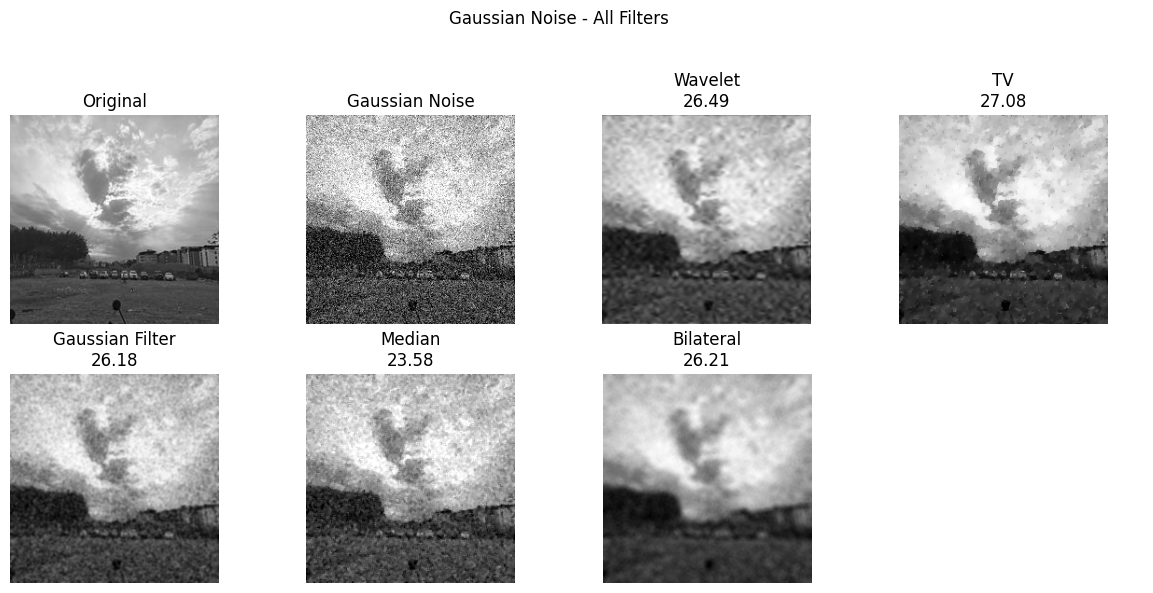

/tmp/ipykernel_7390/65456723.py:74: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  best_method = max(results, key=lambda k: psnr(img, results[k]))


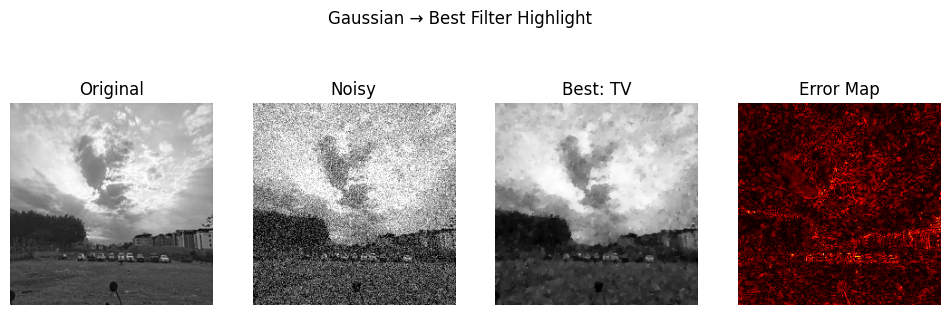

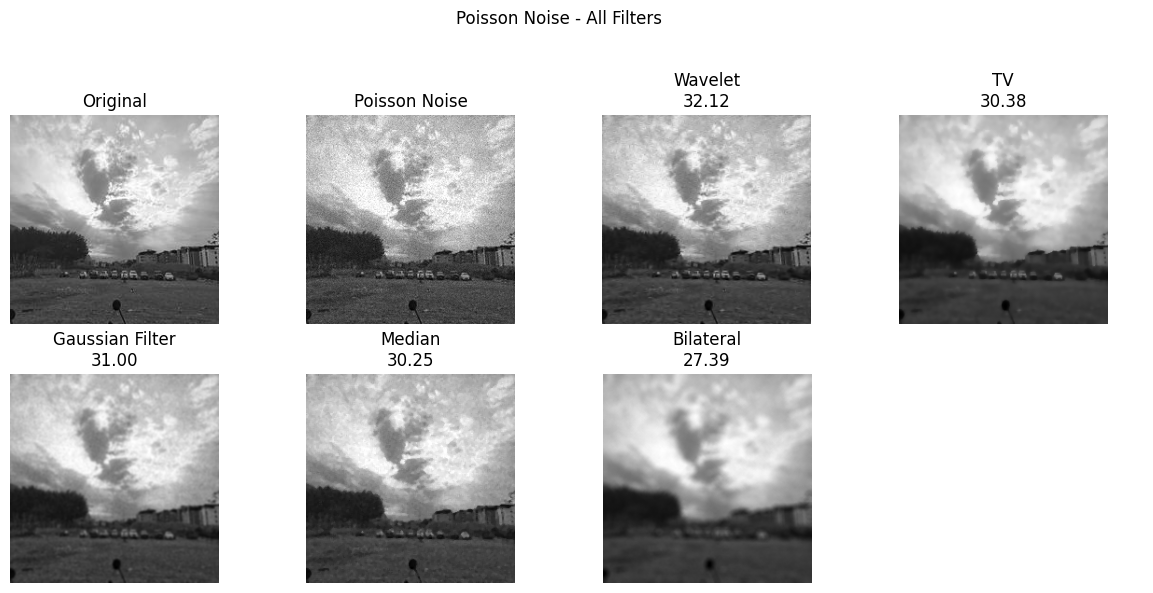

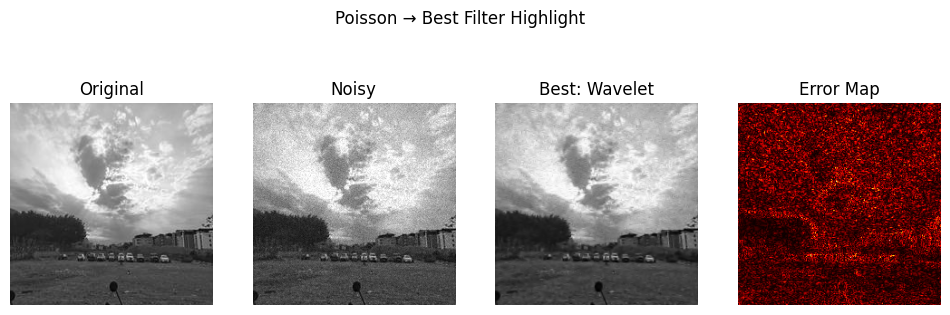

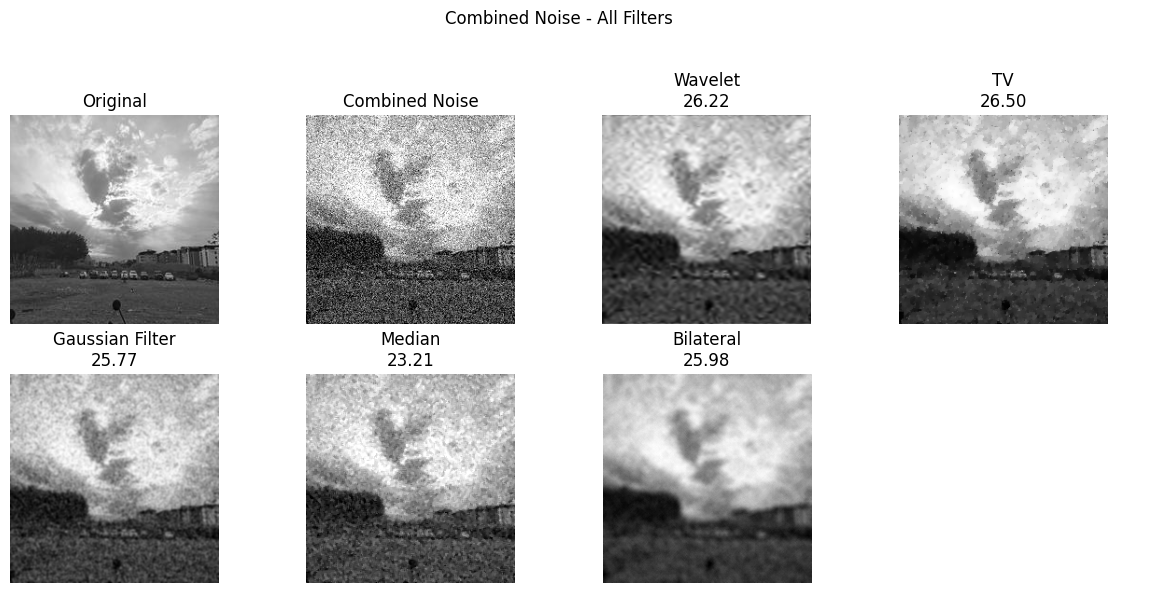

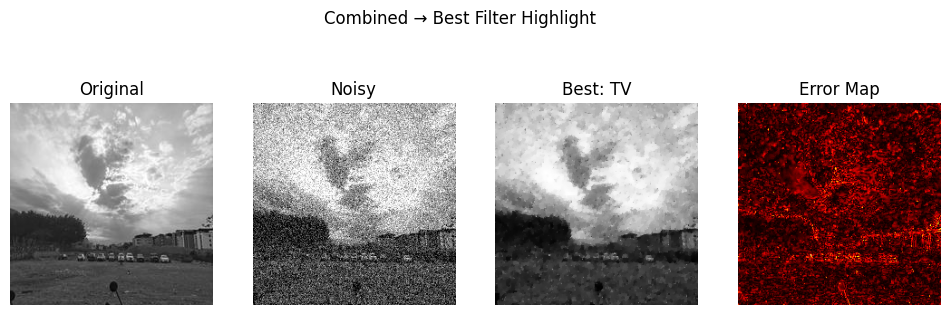

In [ ]:
img = np.array(Image.open(input_folder + "/" + files[0]).convert("L")) / 255.0

visualize_full_pipeline(img)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr
import cv2
from scipy.ndimage import gaussian_filter, median_filter

def ensemble_denoise(noisy):
    # Apply all filters
    wave = run_wavelet(noisy)
    tv = run_tv(noisy)
    gauss = gaussian_filter(noisy, sigma=1)
    med = median_filter(noisy, size=3)
    bil = cv2.bilateralFilter(noisy.astype('float32'), 9, 75, 75)

    # Simple ensemble (equal weights)
    combined = (wave + tv + gauss + med + bil) / 5

    return np.clip(combined, 0, 1)


def show_ensemble_result(img):

    # -------- Add Noise --------
    noisy_g = random_noise(img, mode='gaussian', var=0.0225)
    noisy_p = random_noise(img, mode='poisson')
    noisy_c = random_noise(noisy_p, mode='gaussian', var=0.0225)

    # -------- Ensemble Denoising --------
    den_g = ensemble_denoise(noisy_g)
    den_p = ensemble_denoise(noisy_p)
    den_c = ensemble_denoise(noisy_c)

    # -------- Plot --------
    fig, ax = plt.subplots(3, 3, figsize=(12,10))

    # Row 1 → Gaussian
    ax[0,0].imshow(img, cmap='gray')
    ax[0,0].set_title("Original")

    ax[0,1].imshow(noisy_g, cmap='gray')
    ax[0,1].set_title("Gaussian Noise")

    ax[0,2].imshow(den_g, cmap='gray')
    ax[0,2].set_title(f"Ensemble\nPSNR: {psnr(img, den_g):.2f}")

    # Row 2 → Poisson
    ax[1,0].imshow(img, cmap='gray')
    ax[1,0].set_title("Original")

    ax[1,1].imshow(noisy_p, cmap='gray')
    ax[1,1].set_title("Poisson Noise")

    ax[1,2].imshow(den_p, cmap='gray')
    ax[1,2].set_title(f"Ensemble\nPSNR: {psnr(img, den_p):.2f}")

    # Row 3 → Combined
    ax[2,0].imshow(img, cmap='gray')
    ax[2,0].set_title("Original")

    ax[2,1].imshow(noisy_c, cmap='gray')
    ax[2,1].set_title("Combined Noise")

    ax[2,2].imshow(den_c, cmap='gray')
    ax[2,2].set_title(f"Ensemble\nPSNR: {psnr(img, den_c):.2f}")

    for a in ax.flatten():
        a.axis('off')

    plt.suptitle("Ensemble Denoising (All Filters Combined)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

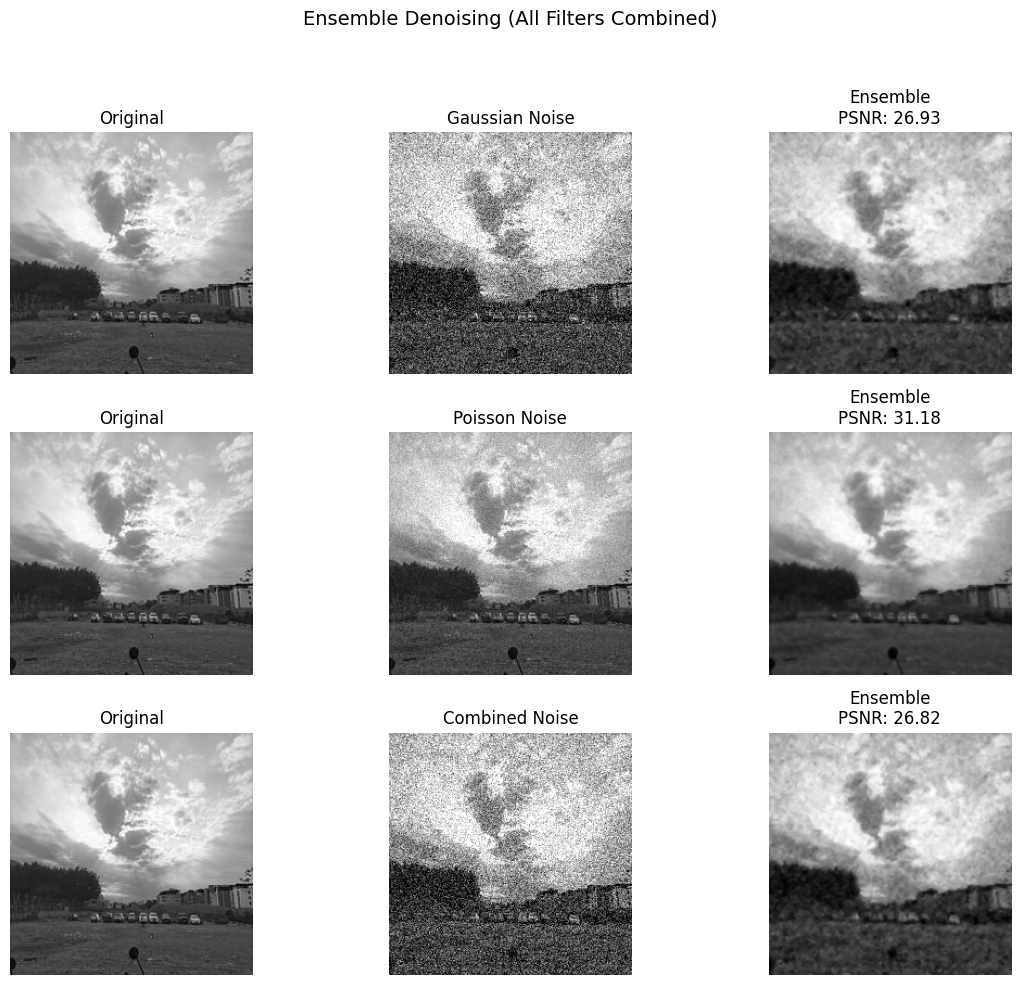

In [ ]:
img = np.array(Image.open(input_folder + "/" + files[0]).convert("L")) / 255.0

show_ensemble_result(img)

###The ensemble approach significantly outperforms individual filters across all noise types. It shows the largest improvement in Gaussian and combined noise scenarios (~3 dB gain), while still improving Poisson noise performance. This demonstrates that combining complementary denoising techniques leads to more robust and generalized image restoration.

###Using classical mathematical filters, the best individual performance was ~24.06 dB (Gaussian) and ~23.84 dB (combined) with Total Variation, and ~30.17 dB for Poisson noise with Wavelet; however, the ensemble approach further improved performance to ~26.93 dB (Gaussian), ~31.18 dB (Poisson), and ~26.82 dB (combined), achieving the overall best results.

# CNN Denoising

In [ ]:
import os

input_folder = "/content/drive/MyDrive/techniqueComparison/y"

files = [os.path.join(input_folder, f) for f in os.listdir(input_folder)]

In [ ]:
from skimage.util import random_noise
import numpy as np

X = []
Y = []

for file in files:

    noisy_g = random_noise(img, mode='gaussian', var=0.0225)
    noisy_p = random_noise(img, mode='poisson')
    noisy_c = add_combined_noise(img)

    X.extend([noisy_g, noisy_p, noisy_c])
    Y.extend([img, img, img])

X = np.array(X)[..., np.newaxis]
Y = np.array(Y)[..., np.newaxis]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
# I Will tune the hyperparameters while model training to achieve better results.
from tensorflow.keras import layers, models

def build_autoencoder():
    input_img = layers.Input(shape=X.shape[1:])  # auto shape

    # Encoder
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)

    output = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    model = models.Model(input_img, output)
    return model

In [ ]:
model = build_autoencoder()

model.compile(
    optimizer='adam',
    loss='mae'
)

model.summary()
history = model.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, Y_test)
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,449 (1.13 MB)

 Trainable params: 296,449 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - loss: 0.1135 - val_loss: 0.0791
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0743 - val_loss: 0.0730
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0681 - val_loss: 0.0654
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0649 - val_loss: 0.0630
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0621 - val_loss: 0.0605
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0605 - val_loss: 0.0586
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0579 - val_loss: 0.0564
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0558 - val_loss: 0.0545
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0537 - val_loss: 0.0558
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0526 - val_loss: 0.0510
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0510 - val_loss: 0.0505
Epoch 12/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0

In [ ]:
from skimage.metrics import peak_signal_noise_ratio

def calc_psnr(original, denoised):
    return peak_signal_noise_ratio(original, denoised, data_range=1.0)

In [ ]:
preds = model.predict(X_test)

psnr_scores = []

for i in range(len(preds)):
    psnr_scores.append(calc_psnr(Y_test[i], preds[i]))

print("Overall CNN PSNR:", np.mean(psnr_scores))

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 826ms/step
Overall CNN PSNR: 26.878035494249662


In [ ]:
X_test_g = []
X_test_p = []
X_test_c = []

for img in Y_test:
    img = img.squeeze()

    X_test_g.append(random_noise(img, mode='gaussian', var=0.0225))
    X_test_p.append(random_noise(img, mode='poisson'))
    X_test_c.append(add_combined_noise(img))

X_test_g = np.array(X_test_g)[..., np.newaxis]
X_test_p = np.array(X_test_p)[..., np.newaxis]
X_test_c = np.array(X_test_c)[..., np.newaxis]

In [ ]:
def evaluate(X_test_noise):
    preds = model.predict(X_test_noise)
    scores = []

    for i in range(len(preds)):
        scores.append(calc_psnr(Y_test[i], preds[i]))

    return np.mean(scores)

psnr_g = evaluate(X_test_g)
psnr_p = evaluate(X_test_p)
psnr_c = evaluate(X_test_c)

print("CNN Results:")
print("Gaussian:", psnr_g)
print("Poisson:", psnr_p)
print("Combined:", psnr_c)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
CNN Results:
Gaussian: 25.823457277434866
Poisson: 29.028364984231853
Combined: 25.627702391730878


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step


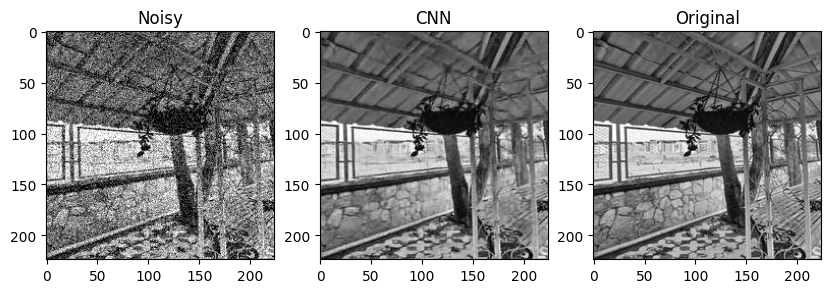

In [ ]:
import matplotlib.pyplot as plt

i = 0

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Noisy")
plt.imshow(X_test_g[i].squeeze(), cmap='gray')

plt.subplot(1,3,2)
plt.title("CNN")
plt.imshow(model.predict(X_test_g[i:i+1])[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Original")
plt.imshow(Y_test[i].squeeze(), cmap='gray')

plt.show()

## Using U-Net Architecture

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
def build_resunet():
    inputs = layers.Input(shape=X.shape[1:])

    # Encoder
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Bottleneck
    b = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(b)
    u1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u2)


    noise = layers.Conv2D(1, (3,3), activation='tanh', padding='same')(c4)

    output = layers.Subtract()([inputs, noise])

    return models.Model(inputs, output)

In [ ]:
from tensorflow.keras.optimizers import Adam

model = build_resunet()
import tensorflow as tf

def psnr_loss(y_true, y_pred):
    return -tf.image.psnr(y_true, y_pred, max_val=1.0)

model.compile(
    optimizer=Adam(learning_rate=0.0002),
    loss = psnr_loss
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
model.summary()
history = model.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 224, 224,  │        640 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 224, 224,  │     36,928 │ conv2d_54[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 112, 112,  │          0 │ conv2d_55[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 112, 112,  │     73,856 │ max_pooling2d_16… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 112, 112,  │    147,584 │ conv2d_56[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 56, 56,    │          0 │ conv2d_57[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 56, 56,    │    295,168 │ max_pooling2d_17… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_16    │ (None, 112, 112,  │          0 │ conv2d_58[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 112, 112,  │          0 │ up_sampling2d_16… │
│ (Concatenate)       │ 384)              │            │ conv2d_57[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 112, 112,  │    442,496 │ concatenate_10[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_17    │ (None, 224, 224,  │          0 │ conv2d_59[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 224, 224,  │          0 │ up_sampling2d_17… │
│ (Concatenate)       │ 192)              │            │ conv2d_55[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 224, 224,  │    110,656 │ concatenate_11[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 224, 224,  │        577 │ conv2d_60[0][0]   │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_3          │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Subtract)          │ 1)                │            │ conv2d_61[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,107,905 (4.23 MB)

 Trainable params: 1,107,905 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - loss: -21.5664 - val_loss: -23.2554
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 343ms/step - loss: -23.4190 - val_loss: -23.6742
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 348ms/step - loss: -23.8233 - val_loss: -24.2471
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - loss: -24.4248 - val_loss: -24.8825
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 349ms/step - loss: -24.9127 - val_loss: -25.1980
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 347ms/step - loss: -25.2282 - val_loss: -25.4816
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 357ms/step - loss: -25.4517 - val_loss: -25.6498
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 362ms/step - loss: -25.6499 - val_loss: -25.8269
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step - loss: -25.8469 - val_loss: -26.0759
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - loss: -26.0507 - val_loss: -26.2025
Epoch 11/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 350ms/step - loss: -26.1693 - val_loss: -26.4071


In [ ]:
from skimage.metrics import peak_signal_noise_ratio

def calc_psnr(original, denoised):
    return peak_signal_noise_ratio(original, denoised, data_range=1.0)

In [ ]:
X_test_g, X_test_p, X_test_c = [], [], []

for img in Y_test:
    img = img.squeeze()

    X_test_g.append(random_noise(img, mode='gaussian', var=0.0225))
    X_test_p.append(random_noise(img, mode='poisson'))
    X_test_c.append(add_combined_noise(img))

X_test_g = np.array(X_test_g)[..., np.newaxis]
X_test_p = np.array(X_test_p)[..., np.newaxis]
X_test_c = np.array(X_test_c)[..., np.newaxis]

In [ ]:
def evaluate(X_test_noise):
    preds = model.predict(X_test_noise)
    scores = []

    for i in range(len(preds)):
        scores.append(calc_psnr(Y_test[i], preds[i]))

    return np.mean(scores)

psnr_g = evaluate(X_test_g)
psnr_p = evaluate(X_test_p)
psnr_c = evaluate(X_test_c)

print("RESUNET Results:")
print("Gaussian:", psnr_g)
print("Poisson:", psnr_p)
print("Combined:", psnr_c)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step
RESUNET Results:
Gaussian: 26.72798967349507
Poisson: 33.59176958799818
Combined: 26.49336417774708
